Now you are upgrading from a **basic camera (fixed axis)** → to a **real 3D camera system (like Blender / OpenGL / Unreal engine style math)**.

This is the *most important camera upgrade in ray tracing*.

---

# 🎯 What changed conceptually?

### ❌ Before (your old camera)

* Camera always faces −Z
* No rotation
* No real orientation system

---

### ✅ Now (this version)

You define:

| Concept    | Meaning                  |
| ---------- | ------------------------ |
| `lookfrom` | camera position          |
| `lookat`   | target point             |
| `vup`      | "up direction" of camera |
| `u, v, w`  | camera coordinate frame  |

---

# 🧠 Core math idea

We build a **camera coordinate system (orthonormal basis)**:

$$
\mathbf{w} = \frac{\text{lookfrom} - \text{lookat}}{|\text{lookfrom} - \text{lookat}|}
$$

$$
\mathbf{u} = \frac{\mathbf{vup} \times \mathbf{w}}{|\mathbf{vup} \times \mathbf{w}|}
$$

$$
\mathbf{v} = \mathbf{w} \times \mathbf{u}
$$

---

# 📊 Meaning of each axis

| Vector | Meaning                                         |
| ------ | ----------------------------------------------- |
| $w$    | backward direction (camera looks opposite this) |
| $u$    | right direction                                 |
| $v$    | up direction                                    |

So camera looks along:

$$
-\mathbf{w}
$$

---

# 📐 Viewport math upgrade

| Step            | Formula              | Purpose                |
| --------------- | -------------------- | ---------------------- |
| focal length    | $lookfrom - lookat$  | camera distance        |
| viewport height | $2 \tan(\theta/2) f$ | FOV scaling            |
| viewport width  | aspect ratio scaling | image shape            |
| pixel step u    | viewport_u / width   | horizontal ray spacing |
| pixel step v    | viewport_v / height  | vertical ray spacing   |

---

# 🧾 FULL PYTHON CAMERA (POSITION + ORIENTATION)

```python id="cam3d_01"
import math
import random

from util.ray import Ray
from util.vec3 import Vec3, unit_vector, cross
from util.interval import Interval
from util.metal.hit_record import HitRecord


class Camera:

    def __init__(self):

        # ==========================
        # IMAGE SETTINGS
        # ==========================
        self.aspect_ratio = 16 / 9
        self.image_width = 400
        self.samples_per_pixel = 100
        self.max_depth = 50

        # ==========================
        # CAMERA CONFIG (NEW)
        # ==========================
        self.vfov = 90

        # CHANGED: new camera controls
        self.lookfrom = Vec3(0, 0, 0)
        self.lookat   = Vec3(0, 0, -1)
        self.vup      = Vec3(0, 1, 0)

    # ==========================
    # INITIALIZATION (BIG UPGRADE)
    # ==========================
    def initialize(self):

        # --------------------------
        # image size
        # --------------------------
        self.image_height = max(
            1,
            int(self.image_width / self.aspect_ratio)
        )

        self.pixel_samples_scale = 1.0 / self.samples_per_pixel

        # ==========================
        # CAMERA BASIS (NEW CORE)
        # ==========================

        # center of camera
        self.center = self.lookfrom  # CHANGED

        # --------------------------
        # w = backward direction
        # --------------------------
        w = unit_vector(self.lookfrom - self.lookat)

        # --------------------------
        # u = right direction
        # --------------------------
        u = unit_vector(cross(self.vup, w))

        # --------------------------
        # v = up direction
        # --------------------------
        v = cross(w, u)

        self.u = u
        self.v = v
        self.w = w

        # ==========================
        # FOV → viewport
        # ==========================
        focal_length = (self.lookfrom - self.lookat).length()

        theta = math.radians(self.vfov)
        h = math.tan(theta / 2)

        viewport_height = 2 * h * focal_length
        viewport_width = viewport_height * (
            self.image_width / self.image_height
        )

        # ==========================
        # viewport axes (ROTATED!)
        # ==========================
        viewport_u = viewport_width * u
        viewport_v = viewport_height * (-v)

        # pixel spacing
        self.pixel_delta_u = viewport_u / self.image_width
        self.pixel_delta_v = viewport_v / self.image_height

        # ==========================
        # top-left pixel position
        # ==========================
        viewport_upper_left = (
            self.center
            - focal_length * w
            - viewport_u / 2
            - viewport_v / 2
        )

        self.pixel00_loc = viewport_upper_left + 0.5 * (
            self.pixel_delta_u + self.pixel_delta_v
        )

    # ==========================
    # RANDOM SAMPLING
    # ==========================
    def sample_square(self):
        return Vec3(
            random.random() - 0.5,
            random.random() - 0.5,
            0
        )

    # ==========================
    # RAY GENERATION (UPDATED)
    # ==========================
    def get_ray(self, i, j):

        offset = self.sample_square()

        pixel_center = (
            self.pixel00_loc
            + (i + offset.x) * self.pixel_delta_u
            + (j + offset.y) * self.pixel_delta_v
        )

        direction = pixel_center - self.center

        return Ray(self.center, direction)

    # ==========================
    # PATH TRACING (UNCHANGED)
    # ==========================
    def ray_color(self, ray, world, depth):

        if depth <= 0:
            return Vec3(0, 0, 0)

        rec = HitRecord()

        hit = world.hit(
            ray,
            Interval(0.001, float("inf")),
            rec
        )

        if hit:
            scattered, attenuation = rec.mat.scatter(ray, rec)

            return attenuation * self.ray_color(
                scattered,
                world,
                depth - 1
            )

        unit_dir = unit_vector(ray.direction())
        t = 0.5 * (unit_dir.y + 1.0)

        return (1 - t) * Vec3(1, 1, 1) + t * Vec3(0.5, 0.7, 1.0)

    # ==========================
    # GAMMA
    # ==========================
    def gamma(self, c):
        return Vec3(
            math.sqrt(c.x),
            math.sqrt(c.y),
            math.sqrt(c.z)
        )

    # ==========================
    # RENDER
    # ==========================
    def render(self, world):

        self.initialize()

        print("P3")
        print(self.image_width, self.image_height)
        print("255")

        for j in range(self.image_height):
            for i in range(self.image_width):

                pixel_color = Vec3(0, 0, 0)

                for _ in range(self.samples_per_pixel):

                    ray = self.get_ray(i, j)

                    pixel_color += self.ray_color(
                        ray,
                        world,
                        self.max_depth
                    )

                pixel_color *= self.pixel_samples_scale
                pixel_color = self.gamma(pixel_color)

                r = min(max(pixel_color.x, 0), 0.999)
                g = min(max(pixel_color.y, 0), 0.999)
                b = min(max(pixel_color.z, 0), 0.999)

                print(int(256*r), int(256*g), int(256*b))
```

---

# 🧠 What changed from your previous camera?

## 📊 Major upgrade table

| Feature     | Old Camera | New Camera           |
| ----------- | ---------- | -------------------- |
| Orientation | fixed -Z   | arbitrary 3D         |
| Rotation    | ❌ none     | ✔ full basis (u,v,w) |
| Look system | none       | lookfrom/lookat      |
| Up control  | implicit   | explicit vup         |
| Realism     | low        | Blender-style camera |

---

# 🎯 Key insight

Now your camera is:

> 🧭 A full 3D coordinate system generator

It is no longer a "screen projector" — it is a **real virtual camera in 3D space**.

---

# 🚀 If you want next upgrade

I can take you further into:

### 🎥 cinematic camera system

* smooth camera animation (path curves)
* orbit camera
* depth of field (real lens blur)
* motion blur (physics-based)
* matrix-based camera (OpenGL style)

Just say 👍


In [20]:
import sys 
sys.path.append("../../Ray Tracing in One Weekend/")

import math
import random

from tqdm import tqdm

from util.ray import Ray
from util.vec3 import Vec3, unit_vector
from util.interval import Interval
from util.metal.hit_record import HitRecord

from util.image_viewer import image_viewer
from util.sys_monitor import system_monitor

from util.metal.lambertian import Lambertian
from util.metal.metal_fuzz import Metal
from util.metal.dielectric import Dielectric
from util.metal.sphere import Sphere
from util.metal.hittable_list import HittableList

from util.sys_monitor import system_monitor

In [21]:
import math
import random
import os

from util.ray import Ray
from util.vec3 import Vec3, unit_vector, cross
from util.interval import Interval
from util.metal.hit_record import HitRecord
from util.image_viewer import image_viewer


class Camera:

    def __init__(self):

        # ==========================
        # IMAGE SETTINGS
        # ==========================
        # CHANGED: same as previous version (no structural change)
        self.aspect_ratio = 16 / 9
        self.image_width = 400
        self.samples_per_pixel = 100
        self.max_depth = 50

        # ==========================
        # CAMERA CONFIG (UNCHANGED CORE IDEA)
        # ==========================
        # CHANGED: introduced explicit FOV + camera pose (same as previous upgrade)
        self.vfov = 90  # vertical field of view in degrees

        # camera position (origin point in world space)
        self.lookfrom = Vec3(0, 0, 0)

        # point camera is looking at
        self.lookat   = Vec3(0, 0, -1)

        # "world up direction"
        self.vup      = Vec3(0, 1, 0)

        # output file for PPM renderer
        self.output_file = "output.ppm"

    # ==========================
    # CAMERA INITIALIZATION
    # ==========================
    def initialize(self):

        # --------------------------------------------------
        # 1. IMAGE HEIGHT FROM ASPECT RATIO
        # --------------------------------------------------
        # CHANGED: same as earlier version
        self.image_height = max(
            1,
            int(self.image_width / self.aspect_ratio)
        )

        # scale factor for averaging samples per pixel
        self.pixel_samples_scale = 1.0 / self.samples_per_pixel

        # ==================================================
        # 2. CAMERA POSITION
        # ==================================================
        # CHANGED: now camera is NOT fixed at origin logically
        self.center = self.lookfrom

        # ==================================================
        # 3. CAMERA ORTHONORMAL BASIS (CORE CHANGE)
        # ==================================================
        # This is the biggest upgrade from earlier version

        # w = backward direction (camera looks opposite w)
        # FORMULA:
        # w = normalize(lookfrom - lookat)
        w = unit_vector(self.lookfrom - self.lookat)

        # u = right direction
        # FORMULA:
        # u = normalize(vup × w)
        u = unit_vector(cross(self.vup, w))

        # v = true up direction (orthogonal corrected)
        # FORMULA:
        # v = w × u
        v = cross(w, u)

        # store basis vectors
        self.u, self.v, self.w = u, v, w

        # ==================================================
        # 4. FIELD OF VIEW → VIEWPORT SIZE
        # ==================================================
        # CHANGED: earlier version used fixed viewport size (2.0)
        # NOW: dynamic based on vfov

        # distance from camera to view plane
        focal_length = (self.lookfrom - self.lookat).length()

        # convert FOV degrees → radians
        theta = math.radians(self.vfov)

        # half-angle tangent gives viewport scaling
        h = math.tan(theta / 2)

        # FORMULA:
        # viewport_height = 2 * tan(fov/2) * focal_length
        viewport_height = 2 * h * focal_length

        # width depends on aspect ratio
        viewport_width = viewport_height * (
            self.image_width / self.image_height
        )

        # ==================================================
        # 5. CAMERA PLANE AXES (ROTATED SPACE)
        # ==================================================
        # CHANGED: now viewport is aligned to camera orientation

        viewport_u = viewport_width * u
        viewport_v = viewport_height * (-v)

        # pixel step size in 3D space
        self.pixel_delta_u = viewport_u / self.image_width
        self.pixel_delta_v = viewport_v / self.image_height

        # ==================================================
        # 6. TOP LEFT PIXEL POSITION
        # ==================================================
        # CHANGED: now depends on camera orientation + FOV

        viewport_upper_left = (
            self.center
            - focal_length * w      # move forward to screen plane
            - viewport_u / 2        # go left half width
            - viewport_v / 2        # go up half height
        )

        # move to pixel center (not corner)
        self.pixel00_loc = viewport_upper_left + 0.5 * (
            self.pixel_delta_u + self.pixel_delta_v
        )

    # ==========================
    # RANDOM SAMPLING (ANTI-ALIASING)
    # ==========================
    def sample_square(self):
        # CHANGED: unchanged concept
        # adds jitter inside pixel
        return Vec3(
            random.random() - 0.5,
            random.random() - 0.5,
            0
        )

    # ==========================
    # RAY GENERATION
    # ==========================
    def get_ray(self, i, j):

        # CHANGED: unchanged logic but now camera is oriented in 3D

        offset = self.sample_square()

        # compute pixel position in 3D space
        pixel_center = (
            self.pixel00_loc
            + (i + offset.x) * self.pixel_delta_u
            + (j + offset.y) * self.pixel_delta_v
        )

        # ray starts at camera center
        direction = pixel_center - self.center

        return Ray(self.center, direction)

    # ==========================
    # PATH TRACING CORE
    # ==========================
    def ray_color(self, ray, world, depth):

        # STOP CONDITION (prevents infinite recursion)
        if depth <= 0:
            return Vec3(0, 0, 0)

        rec = HitRecord()

        # CHANGED: world hit uses interval to avoid self-intersection
        hit = world.hit(
            ray,
            Interval(0.001, float("inf")),
            rec
        )

        # ==================================================
        # IF HIT OBJECT
        # ==================================================
        if hit:

            # material decides scattering
            scattered, attenuation = rec.mat.scatter(ray, rec)

            # recursive bounce (light transport equation)
            return attenuation * self.ray_color(
                scattered,
                world,
                depth - 1
            )

        # ==================================================
        # SKY COLOR (NO HIT CASE)
        # ==================================================
        unit_dir = unit_vector(ray.direction())

        # map y direction to 0..1 range
        t = 0.5 * (unit_dir.y + 1.0)

        # linear interpolation
        return (1 - t) * Vec3(1, 1, 1) + t * Vec3(0.5, 0.7, 1.0)

    # ==========================
    # GAMMA CORRECTION
    # ==========================
    def gamma(self, c):

        # CHANGED: unchanged concept, fixes brightness perception
        return Vec3(
            math.sqrt(c.x),
            math.sqrt(c.y),
            math.sqrt(c.z)
        )

    # ==========================
    # RENDER TO PPM FILE
    # ==========================
    def render(self, world):

        # initialize camera (builds geometry)
        self.initialize()

        # CHANGED: now writes to FILE instead of print
        with open(self.output_file, "w") as f:

            # ==========================
            # PPM HEADER (mandatory format)
            # ==========================
            f.write("P3\n")  # ASCII PPM format
            f.write(f"{self.image_width} {self.image_height}\n")
            f.write("255\n")  # max color value

            # loop over image rows
            pbar = tqdm(range(self.image_height))

            for j in pbar:

                if j % 5 == 0:
                    pbar.set_postfix(system_monitor())

                # loop over pixels in row
                for i in range(self.image_width):

                    pixel_color = Vec3(0, 0, 0)

                    # MULTI-SAMPLING (anti-aliasing)
                    for _ in range(self.samples_per_pixel):

                        ray = self.get_ray(i, j)

                        pixel_color += self.ray_color(
                            ray,
                            world,
                            self.max_depth
                        )

                    # average samples
                    pixel_color *= self.pixel_samples_scale

                    # gamma correction
                    pixel_color = self.gamma(pixel_color)

                    # clamp to valid range [0,1)
                    r = min(max(pixel_color.x, 0), 0.999)
                    g = min(max(pixel_color.y, 0), 0.999)
                    b = min(max(pixel_color.z, 0), 0.999)

                    # write pixel in PPM format
                    f.write(f"{int(256*r)} {int(256*g)} {int(256*b)}\n")

        # confirmation
        print(f"Render complete → {self.output_file}")

    # ==========================
    # SHOW IMAGE
    # ==========================
    def show(self):

        # CHANGED: safety check added
        if not os.path.exists(self.output_file):
            raise FileNotFoundError(
                "Run render() first to generate PPM file"
            )

        return image_viewer(self.output_file)

In [22]:
# ===============================
# SCENE SETUP (PYTHON VERSION)
# ===============================

import math

# --------------------------------
# 1. Create world (scene container)
# --------------------------------
world = HittableList()

# --------------------------------
# 2. MATERIALS
# --------------------------------
material_ground = Lambertian(Vec3(0.8, 0.8, 0.0))
material_center = Lambertian(Vec3(0.1, 0.2, 0.5))

# glass (dielectric)
material_left   = Dielectric(1.50)

# hollow glass (air bubble inside glass)
material_bubble = Dielectric(1.00 / 1.50)

# metal sphere
material_right  = Metal(Vec3(0.8, 0.6, 0.2), fuzz=1.0)

# --------------------------------
# 3. GEOMETRY (SPHERES)
# --------------------------------

# ground (big sphere acting as floor)
world.add(
    Sphere(
        center=Vec3(0.0, -100.5, -1.0),
        radius=100.0,
        material=material_ground
    )
)

# center sphere
world.add(
    Sphere(
        center=Vec3(0.0, 0.0, -1.2),
        radius=0.5,
        material=material_center
    )
)

# left glass sphere
world.add(
    Sphere(
        center=Vec3(-1.0, 0.0, -1.0),
        radius=0.5,
        material=material_left
    )
)

# hollow bubble (same center, smaller radius)
world.add(
    Sphere(
        center=Vec3(-1.0, 0.0, -1.0),
        radius=0.4,
        material=material_bubble
    )
)

# right metal sphere
world.add(
    Sphere(
        center=Vec3(1.0, 0.0, -1.0),
        radius=0.5,
        material=material_right
    )
)

# --------------------------------
# 4. CAMERA SETUP
# --------------------------------
cam = Camera()

# image settings
cam.aspect_ratio = 16.0 / 9.0
cam.image_width = 400
cam.samples_per_pixel = 100
cam.max_depth = 50

# --------------------------------
# 5. CAMERA POSITION (IMPORTANT PART)
# --------------------------------

# CHANGED FROM BASIC CAMERA:
# now using full lookfrom/lookat system

cam.vfov = 90

cam.lookfrom = Vec3(-2, 2, 1)   # camera position in 3D space
cam.lookat   = Vec3(0, 0, -1)   # focus point
cam.vup      = Vec3(0, 1, 0)    # up direction (keeps horizon stable)

# --------------------------------
# 6. RENDER SCENE
# --------------------------------
cam.render(world)



100%|██████████| 225/225 [06:02<00:00,  1.61s/it, CPU=57.4%, RAM=80.8%, CPU Temp=N/A, GPU Temp=50.0°C, VRAM=675.0MB]

Render complete → output.ppm


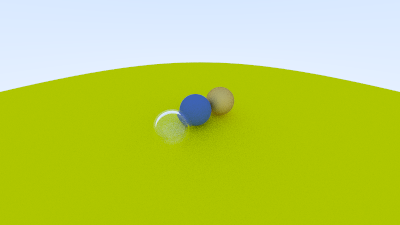

In [23]:
# --------------------------------
# 7. VIEW OUTPUT (optional)
# --------------------------------
cam.show()

In [24]:
cam.vfov     = 20;
cam.render(world)



100%|██████████| 225/225 [14:44<00:00,  3.93s/it, CPU=41.2%, RAM=82.1%, CPU Temp=N/A, GPU Temp=52.0°C, VRAM=774.0MB]

Render complete → output.ppm


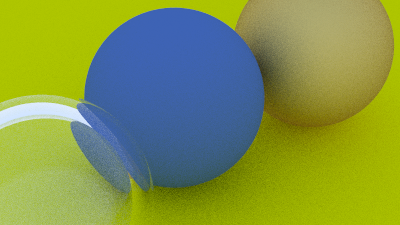

In [25]:
cam.show()